# 📊 Phase 1: EDA & Preprocessing
**Project:** Consumer Behavior Prediction & Precision Marketing  
**Dataset:** UCI Online Shoppers Purchasing Intention Dataset  
---

## 1️⃣ Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
print('✅ Libraries imported!')

✅ Libraries imported!


## 2️⃣ Load Data

In [3]:
df = pd.read_csv('../data/online_shoppers_intention.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (12330, 18)
Columns: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 3️⃣ Basic Info & Missing Values

In [4]:
print('📊 Data Types:')
print(df.dtypes)
print('\n📊 Missing Values:')
print(df.isnull().sum())
print('\n📊 Basic Statistics:')
df.describe()

📊 Data Types:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

📊 Missing Values:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
Oper

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


## 4️⃣ Target Distribution

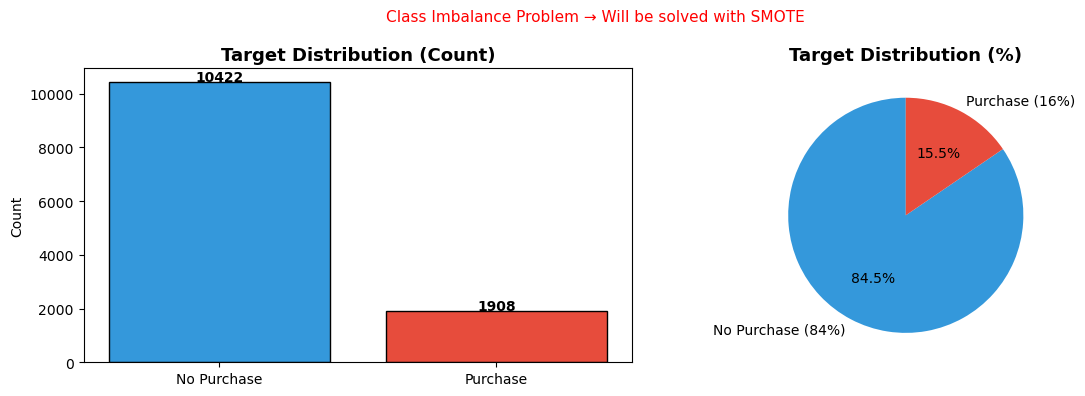

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['Revenue'].value_counts()

axes[0].bar(['No Purchase', 'Purchase'], counts.values, color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0].set_title('Target Distribution (Count)', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['No Purchase (84%)', 'Purchase (16%)'],
            colors=['#3498db', '#e74c3c'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Target Distribution (%)', fontweight='bold', fontsize=13)

plt.suptitle('Class Imbalance Problem → Will be solved with SMOTE', fontsize=11, color='red')
plt.tight_layout()
plt.savefig('../outputs/figures/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 5️⃣ Correlation Matrix

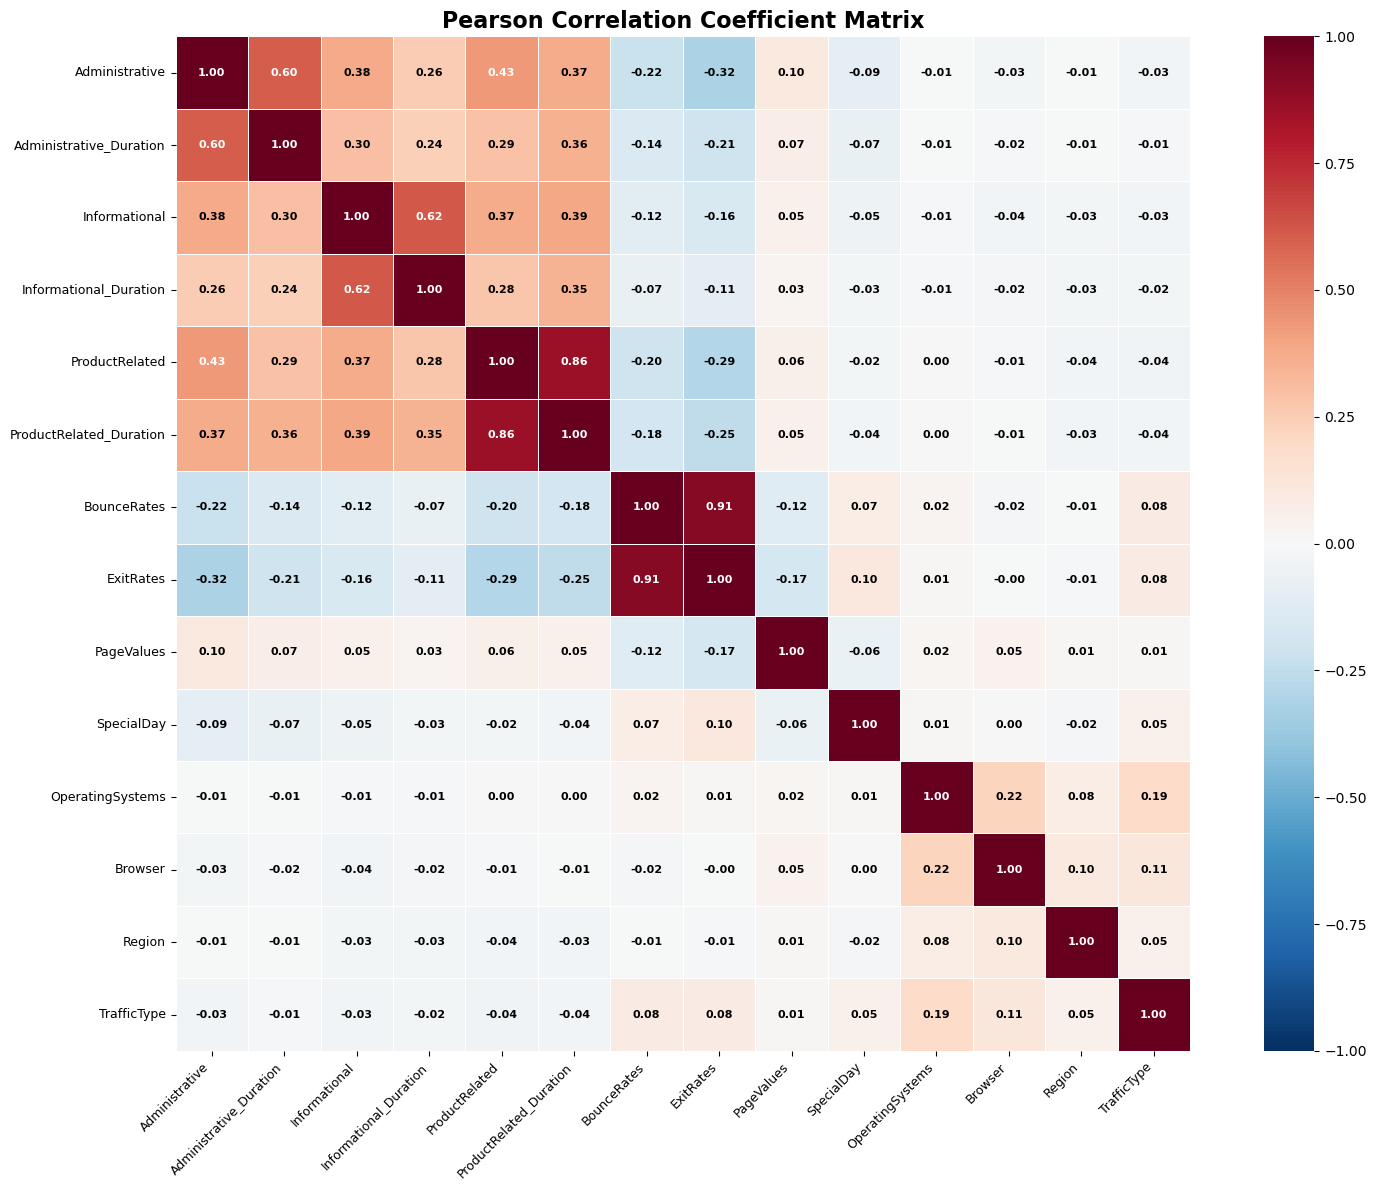

In [ ]:
import matplotlib
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(16, 12))
ax = sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.4:
            color = 'white'
        else:
            color = 'black'
        ax.text(j + 0.5, i + 0.5, f'{val:.2f}',
                ha='center', va='center',
                fontsize=8, fontweight='bold', color=color)

plt.title('Pearson Correlation Coefficient Matrix', fontsize=16, fontweight='bold')
plt.xticks(fontsize=9, rotation=45, ha='right')
plt.yticks(fontsize=9, rotation=0)
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## 6️⃣ Preprocessing Pipeline
```
Raw Data → Label Encoding → Standard Scaling → SMOTE → Train/Test Split
```

In [7]:
df_p = df.copy()

# Step 1: Label Encoding
le = LabelEncoder()
df_p['Month'] = le.fit_transform(df_p['Month'])
df_p['VisitorType'] = le.fit_transform(df_p['VisitorType'])
df_p['Weekend'] = df_p['Weekend'].astype(int)
df_p['Revenue'] = df_p['Revenue'].astype(int)

X = df_p.drop('Revenue', axis=1)
y = df_p['Revenue']

# Step 2: Standard Scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print('✅ Step 1 & 2 Done: Encoding + Scaling')

# Step 3: SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)
print(f'✅ Step 3 Done: SMOTE → {pd.Series(y_res).value_counts().to_dict()}')

# Step 4: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.20, random_state=42, stratify=y_res)
print(f'✅ Step 4 Done: Train={X_train.shape} | Test={X_test.shape}')

✅ Step 1 & 2 Done: Encoding + Scaling


✅ Step 3 Done: SMOTE → {0: 10422, 1: 10422}
✅ Step 4 Done: Train=(16675, 17) | Test=(4169, 17)


## ✅ Summary
| Step | Detail | Result |
|---|---|---|
| Dataset | Rows × Columns | 12,330 × 18 |
| Missing Values | Any nulls? | None ✅ |
| Class Imbalance | Before SMOTE | 84% No / 16% Yes |
| After SMOTE | Balanced | 10,422 vs 10,422 |
| Train Size | 80% | 16,675 samples |
| Test Size | 20% | 4,169 samples |